## plotting


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [6]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    res = STL(x, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [10]:
out5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5.nc')
out5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_extensions.nc')

In [11]:
out5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over.nc')
out5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over_extensions.nc')

In [12]:
out3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp3.nc')

In [13]:
out2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp2.nc')
# out2_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp2_extensions.nc')

In [14]:
out1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp1.nc')
out1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp1_extensions.nc')

In [15]:
xx, yy = np.meshgrid(out5.lon, out5.lat)

In [16]:
# plt.style.use('default')

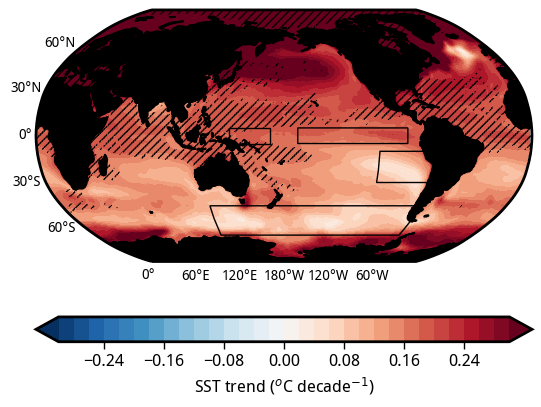

In [17]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(out5.pval_agreement, 0.8)
out5.trend.mean('model').plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))


# plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

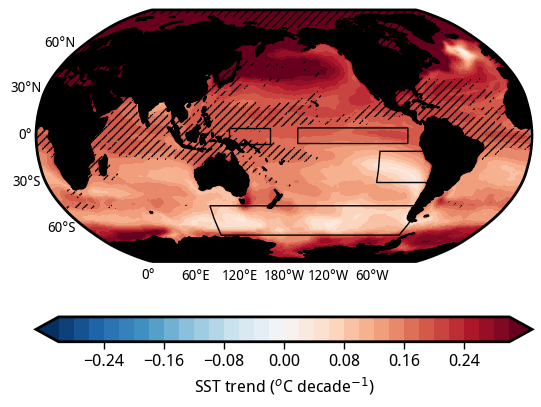

In [44]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(out2.pval_agreement, 0.8)
out2.trend.mean('model').plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))


# plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

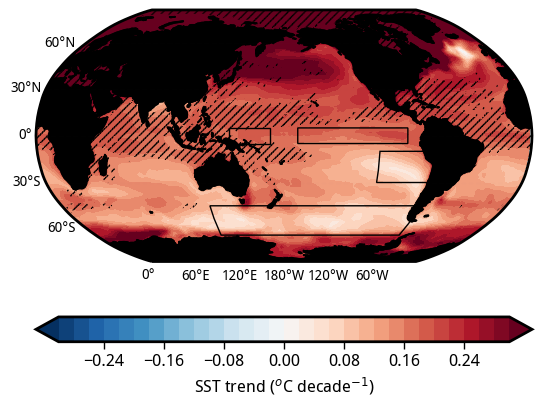

In [45]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(out1.pval_agreement, 0.8)
out1.trend.mean('model').plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))


# plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

(-0.22, 0.62)

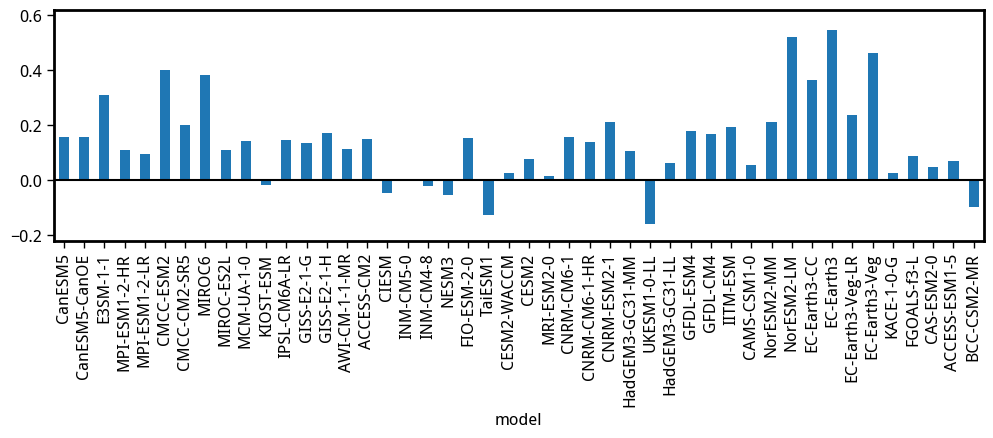

In [55]:
plt.figure(figsize=(12,3))
n34_21c = out5.nino34_index.sel(time = slice('2000', '2099')).std('time')
n34_20c = out5.nino34_index.sel(time = slice('1900', '1999')).std('time')
(n34_21c - n34_20c).to_series().plot.bar()
plt.axhline(0.0, color='k')
plt.ylim(-0.22, 0.62)

(-0.22, 0.62)

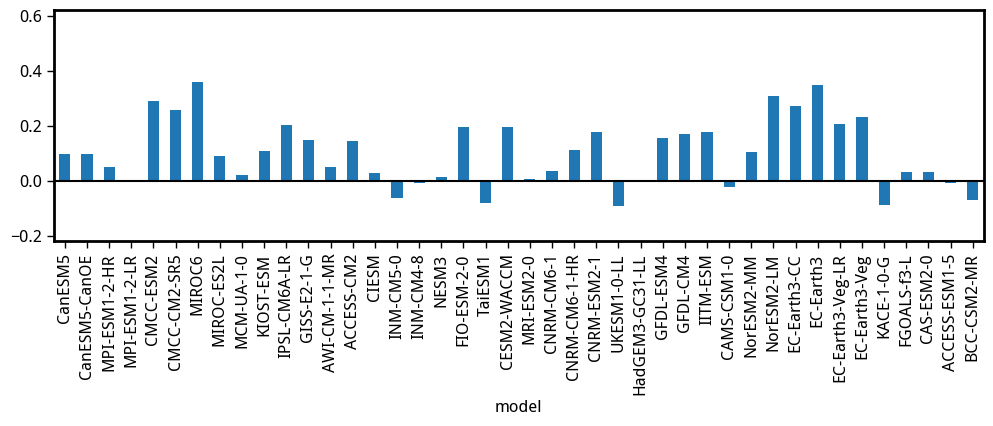

In [56]:
plt.figure(figsize=(12,3))
n34_21c = out2.nino34_index.sel(time = slice('2000', '2099')).std('time')
n34_20c = out2.nino34_index.sel(time = slice('1900', '1999')).std('time')
(n34_21c - n34_20c).to_series().plot.bar()
plt.axhline(0.0, color='k')
plt.ylim(-0.22, 0.62)

(-0.22, 0.62)

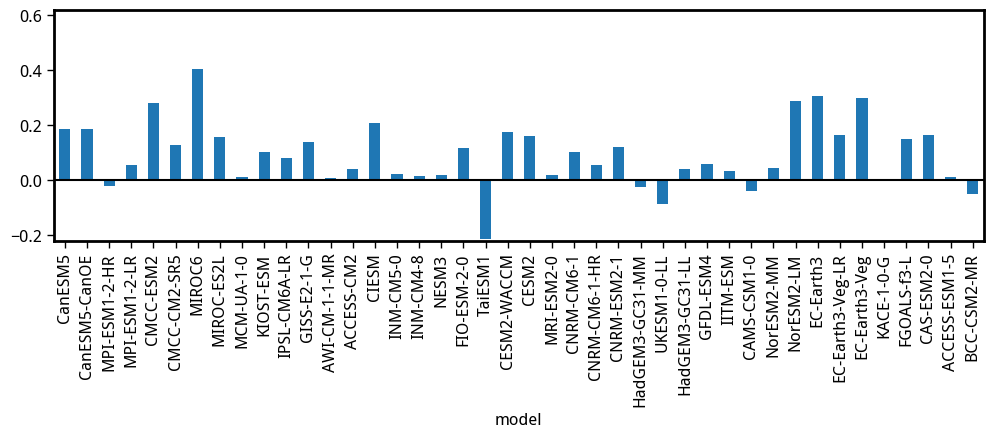

In [57]:
plt.figure(figsize=(12,3))
n34_21c = out1.nino34_index.sel(time = slice('2000', '2099')).std('time')
n34_20c = out1.nino34_index.sel(time = slice('1900', '1999')).std('time')
(n34_21c - n34_20c).to_series().plot.bar()
plt.axhline(0.0, color='k')
plt.ylim(-0.22, 0.62)

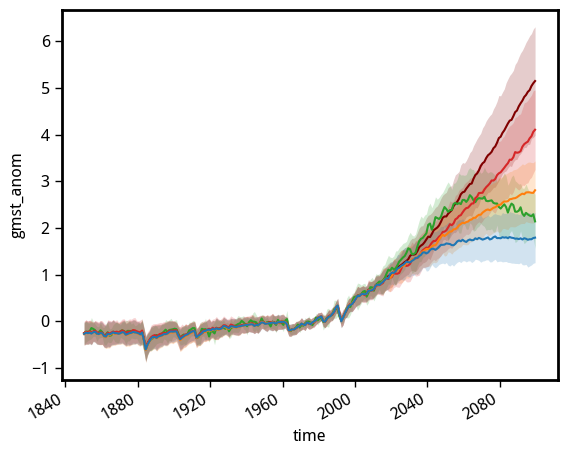

In [16]:
out5.gmst_anom.mean('model').plot(color='maroon')
plt.fill_between(out5.time.to_numpy(), out5.gmst_anom.mean('model') + out5.gmst_anom.std('model'), out5.gmst_anom.mean('model') - out5.gmst_anom.std('model'), color='maroon', alpha=0.2, lw=0.)

out5o.gmst_anom.mean('model').plot(color='tab:green')
plt.fill_between(out5o.time.to_numpy(), out5o.gmst_anom.mean('model') + out5o.gmst_anom.std('model'), out5o.gmst_anom.mean('model') - out5o.gmst_anom.std('model'), color='tab:green', alpha=0.2, lw=0.)

out3.gmst_anom.mean('model').plot(color='tab:red')
plt.fill_between(out3.time.to_numpy(), out3.gmst_anom.mean('model') + out3.gmst_anom.std('model'), out3.gmst_anom.mean('model') - out3.gmst_anom.std('model'), color='tab:red', alpha=0.2, lw=0.)

out2.gmst_anom.mean('model').plot(color='tab:orange')
plt.fill_between(out2.time.to_numpy(), out2.gmst_anom.mean('model') + out2.gmst_anom.std('model'), out2.gmst_anom.mean('model') - out2.gmst_anom.std('model'), color='tab:orange', alpha=0.2, lw=0.)

out1.gmst_anom.mean('model').plot(color='tab:blue')
plt.fill_between(out1.time.to_numpy(), out1.gmst_anom.mean('model') + out1.gmst_anom.std('model'), out1.gmst_anom.mean('model') - out1.gmst_anom.std('model'), color='tab:blue', alpha=0.2, lw=0.)

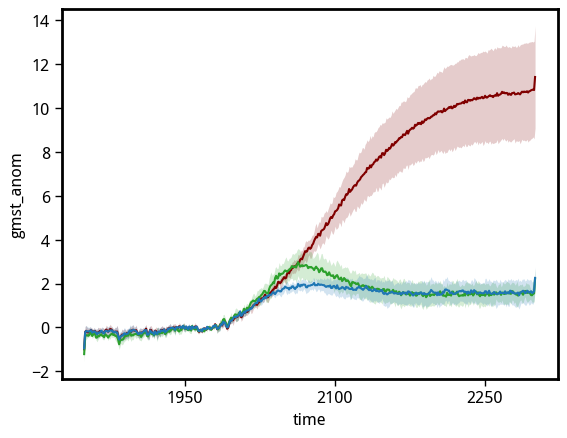

In [17]:
out5_ext.gmst_anom.mean('model').plot(color='maroon')
plt.fill_between(out5_ext.time.to_numpy(), out5_ext.gmst_anom.mean('model') + out5_ext.gmst_anom.std('model'), out5_ext.gmst_anom.mean('model') - out5_ext.gmst_anom.std('model'), color='maroon', alpha=0.2, lw=0.)

out5o_ext.gmst_anom.mean('model').plot(color='tab:green')
plt.fill_between(out5o_ext.time.to_numpy(), out5o_ext.gmst_anom.mean('model') + out5o_ext.gmst_anom.std('model'), out5o_ext.gmst_anom.mean('model') - out5o_ext.gmst_anom.std('model'), color='tab:green', alpha=0.2, lw=0.)

# out2.gmst_anom.mean('model').plot(color='tab:orange')
# plt.fill_between(out2.time.to_numpy(), out2.gmst_anom.mean('model') + out2.gmst_anom.std('model'), out2.gmst_anom.mean('model') - out2.gmst_anom.std('model'), color='tab:orange', alpha=0.2, lw=0.)

out1_ext.gmst_anom.mean('model').plot(color='tab:blue')
plt.fill_between(out1_ext.time.to_numpy(), out1_ext.gmst_anom.mean('model') + out1_ext.gmst_anom.std('model'), out1_ext.gmst_anom.mean('model') - out1_ext.gmst_anom.std('model'), color='tab:blue', alpha=0.2, lw=0.)

In [18]:
out5_roll = out5.rolling(time = 15, center=False).mean('time')
out5o_roll = out5o.rolling(time = 15, center=False).mean('time')
out3_roll = out3.rolling(time = 15, center=False).mean('time')
out2_roll = out2.rolling(time = 15, center=False).mean('time')
out1_roll = out1.rolling(time = 15, center=False).mean('time')

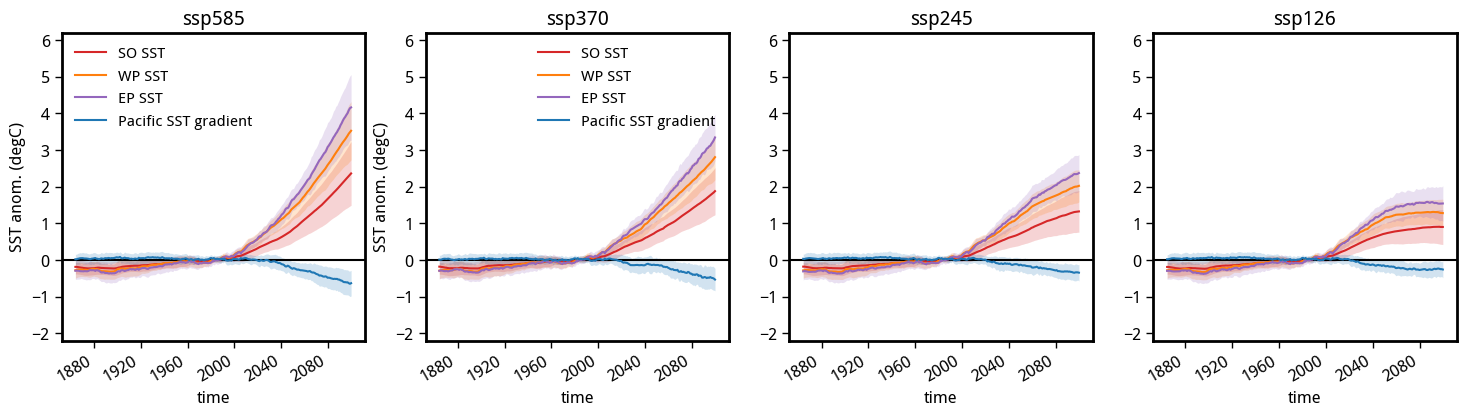

In [20]:
plt.figure(figsize=(18,4))

plt.subplot(141)
plt.axhline(0.0, color='k')
out5_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(out5_roll.time.to_numpy(), out5_roll.so_sst.mean('model') + out5_roll.so_sst.std('model'), out5_roll.so_sst.mean('model') - out5_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out5_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(out5_roll.time.to_numpy(), out5_roll.wp_sst.mean('model') + out5_roll.wp_sst.std('model'), out5_roll.wp_sst.mean('model') - out5_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out5_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(out5_roll.time.to_numpy(), out5_roll.ep_sst.mean('model') + out5_roll.ep_sst.std('model'), out5_roll.ep_sst.mean('model') - out5_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out5_roll.wp_sst - out5_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(out5_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585')


plt.subplot(142)
plt.axhline(0.0, color='k')
out3_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(out3_roll.time.to_numpy(), out3_roll.so_sst.mean('model') + out3_roll.so_sst.std('model'), out3_roll.so_sst.mean('model') - out3_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out3_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(out3_roll.time.to_numpy(), out3_roll.wp_sst.mean('model') + out3_roll.wp_sst.std('model'), out3_roll.wp_sst.mean('model') - out3_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out3_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(out3_roll.time.to_numpy(), out3_roll.ep_sst.mean('model') + out3_roll.ep_sst.std('model'), out3_roll.ep_sst.mean('model') - out3_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out3_roll.wp_sst - out3_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(out3_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp370')


plt.subplot(143)
plt.axhline(0.0, color='k')
out2_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(out2_roll.time.to_numpy(), out2_roll.so_sst.mean('model') + out2_roll.so_sst.std('model'), out2_roll.so_sst.mean('model') - out2_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out2_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(out2_roll.time.to_numpy(), out2_roll.wp_sst.mean('model') + out2_roll.wp_sst.std('model'), out2_roll.wp_sst.mean('model') - out2_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out2_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(out2_roll.time.to_numpy(), out2_roll.ep_sst.mean('model') + out2_roll.ep_sst.std('model'), out2_roll.ep_sst.mean('model') - out2_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out2_roll.wp_sst - out2_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(out2_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp245')


plt.subplot(144)
plt.axhline(0.0, color='k')
out1_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(out1_roll.time.to_numpy(), out1_roll.so_sst.mean('model') + out1_roll.so_sst.std('model'), out1_roll.so_sst.mean('model') - out1_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out1_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(out1_roll.time.to_numpy(), out1_roll.wp_sst.mean('model') + out1_roll.wp_sst.std('model'), out1_roll.wp_sst.mean('model') - out1_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out1_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(out1_roll.time.to_numpy(), out1_roll.ep_sst.mean('model') + out1_roll.ep_sst.std('model'), out1_roll.ep_sst.mean('model') - out1_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out1_roll.wp_sst - out1_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(out1_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.title('ssp126')
plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'ssp534_over')

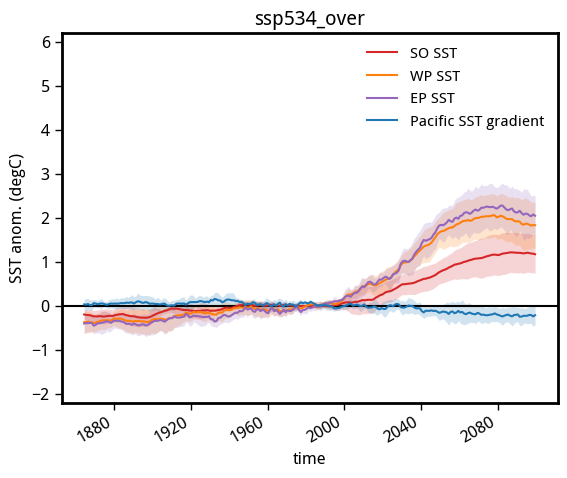

In [21]:
plt.axhline(0.0, color='k')
out5o_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(out5o_roll.time.to_numpy(), out5o_roll.so_sst.mean('model') + out5o_roll.so_sst.std('model'), out5o_roll.so_sst.mean('model') - out5o_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out5o_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(out5o_roll.time.to_numpy(), out5o_roll.wp_sst.mean('model') + out5o_roll.wp_sst.std('model'), out5o_roll.wp_sst.mean('model') - out5o_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out5o_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(out5o_roll.time.to_numpy(), out5o_roll.ep_sst.mean('model') + out5o_roll.ep_sst.std('model'), out5o_roll.ep_sst.mean('model') - out5o_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out5o_roll.wp_sst - out5o_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(out5o_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 6.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp534_over')

In [15]:
out5_ext_roll = out5_ext.rolling(time = 15, center=False).mean('time')
out5o_ext_roll = out5o_ext.rolling(time = 15, center=False).mean('time')
out1_ext_roll = out1_ext.rolling(time = 15, center=False).mean('time')

2024-10-29 22:55:36,437 [WARNING]: legend.py(_parse_legend_args:1217) >> No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


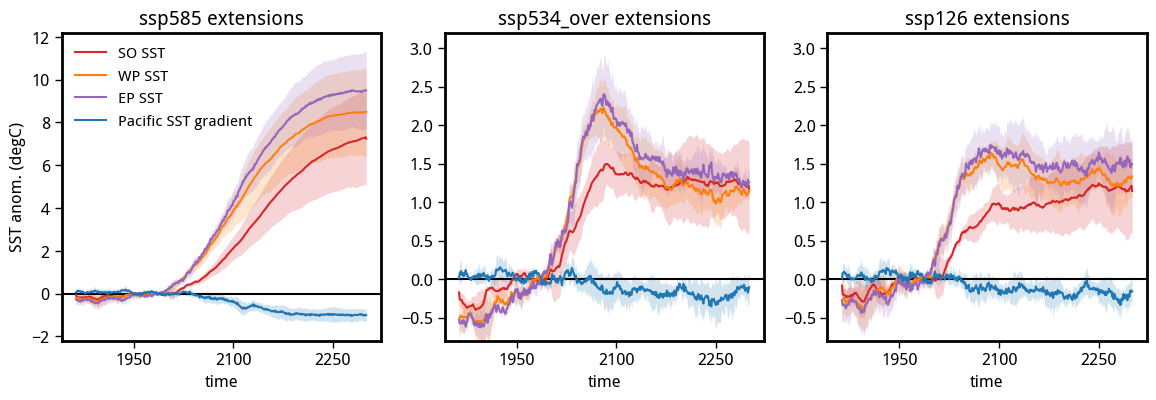

In [16]:
plt.figure(figsize=(14,4))

plt.subplot(131)
plt.axhline(0.0, color='k')
out5_ext_roll.so_sst.mean('model').plot(color='tab:red', label='SO SST')
plt.fill_between(out5_ext_roll.time.to_numpy(), out5_ext_roll.so_sst.mean('model') + out5_ext_roll.so_sst.std('model'), out5_ext_roll.so_sst.mean('model') - out5_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out5_ext_roll.wp_sst.mean('model').plot(color='tab:orange', label='WP SST')
plt.fill_between(out5_ext_roll.time.to_numpy(), out5_ext_roll.wp_sst.mean('model') + out5_ext_roll.wp_sst.std('model'), out5_ext_roll.wp_sst.mean('model') - out5_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out5_ext_roll.ep_sst.mean('model').plot(color='tab:purple', label='EP SST')
plt.fill_between(out5_ext_roll.time.to_numpy(), out5_ext_roll.ep_sst.mean('model') + out5_ext_roll.ep_sst.std('model'), out5_ext_roll.ep_sst.mean('model') - out5_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out5_ext_roll.wp_sst - out5_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue', label='Pacific SST gradient')
plt.fill_between(out5_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-2.2, 12.2)
plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp585 extensions')


plt.subplot(132)
plt.axhline(0.0, color='k')
out5o_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(out5o_ext_roll.time.to_numpy(), out5o_ext_roll.so_sst.mean('model') + out5o_ext_roll.so_sst.std('model'), out5o_ext_roll.so_sst.mean('model') - out5o_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out5o_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(out5o_ext_roll.time.to_numpy(), out5o_ext_roll.wp_sst.mean('model') + out5o_ext_roll.wp_sst.std('model'), out5o_ext_roll.wp_sst.mean('model') - out5o_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out5o_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(out5o_ext_roll.time.to_numpy(), out5o_ext_roll.ep_sst.mean('model') + out5o_ext_roll.ep_sst.std('model'), out5o_ext_roll.ep_sst.mean('model') - out5o_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out5o_ext_roll.wp_sst - out5o_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(out5o_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
# plt.ylabel('SST anom. (degC)')
plt.legend(frameon=False, fontsize=11)
plt.title('ssp534_over extensions')


plt.subplot(133)
plt.axhline(0.0, color='k')
out1_ext_roll.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(out1_ext_roll.time.to_numpy(), out1_ext_roll.so_sst.mean('model') + out1_ext_roll.so_sst.std('model'), out1_ext_roll.so_sst.mean('model') - out1_ext_roll.so_sst.std('model'), color='tab:red', alpha=0.2, lw=0.)
out1_ext_roll.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(out1_ext_roll.time.to_numpy(), out1_ext_roll.wp_sst.mean('model') + out1_ext_roll.wp_sst.std('model'), out1_ext_roll.wp_sst.mean('model') - out1_ext_roll.wp_sst.std('model'), color='tab:orange', alpha=0.2, lw=0.)
out1_ext_roll.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(out1_ext_roll.time.to_numpy(), out1_ext_roll.ep_sst.mean('model') + out1_ext_roll.ep_sst.std('model'), out1_ext_roll.ep_sst.mean('model') - out1_ext_roll.ep_sst.std('model'), color='tab:purple', alpha=0.2, lw=0.)

sst_grad = out1_ext_roll.wp_sst - out1_ext_roll.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(out1_ext_roll.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.2, lw=0.)
plt.ylim(-0.8, 3.2)
plt.title('ssp126 extensions')
plt.savefig('./images/cmip_ext_mmm.png', dpi=300, bbox_inches='tight')

In [19]:
import seaborn as sns

In [43]:
so_warming1 = out1.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming1 = out1.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
sst_grad1 = out1.wp_sst - out1.ep_sst
grad_weakening1 = sst_grad1.sel(time = slice('2070', '2100')).mean('time')

In [44]:
so_warming2 = out2.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming2 = out2.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
sst_grad2 = out2.wp_sst - out2.ep_sst
grad_weakening2 = sst_grad2.sel(time = slice('2070', '2100')).mean('time')

In [45]:
so_warming3 = out3.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming3 = out3.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
sst_grad3 = out3.wp_sst - out3.ep_sst
grad_weakening3 = sst_grad3.sel(time = slice('2070', '2100')).mean('time')

In [46]:
so_warming5o = out5o.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming5o = out5o.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
sst_grad5o = out5o.wp_sst - out5o.ep_sst
grad_weakening5o = sst_grad5o.sel(time = slice('2070', '2100')).mean('time')

In [47]:
so_warming5 = out5.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming5 = out5.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
sst_grad5 = out5.wp_sst - out5.ep_sst
grad_weakening5 = sst_grad5.sel(time = slice('2070', '2100')).mean('time')

In [48]:
so_warming = np.concatenate((so_warming1, so_warming2, so_warming3, so_warming5o, so_warming5))
grad_weakening = np.concatenate((grad_weakening1, grad_weakening2, grad_weakening3, grad_weakening5o, grad_weakening5))
gmst_warming = np.concatenate((gmst_warming1, gmst_warming2, grad_weakening3, gmst_warming5o, gmst_warming5))

In [49]:
grad_weakening.shape

(174,)

In [50]:
so_warming1.quantile(0.75)

<xarray.DataArray 'so_sst' ()>
array(1.16817706)
Coordinates:
    quantile  float64 0.75

PearsonRResult(statistic=-0.41142760478197904, pvalue=1.8735178188038266e-08)

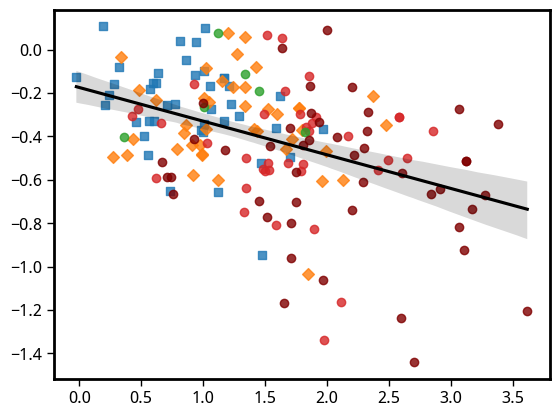

In [54]:
plt.scatter(so_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.8)
plt.scatter(so_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.8)
plt.scatter(so_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.8)
plt.scatter(so_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.8)
plt.scatter(so_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.8)
sns.regplot(x=so_warming, y=grad_weakening, scatter=False, color='k')
stats.pearsonr(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])

SignificanceResult(statistic=-0.38150465860102906, pvalue=2.2337232719672728e-07)

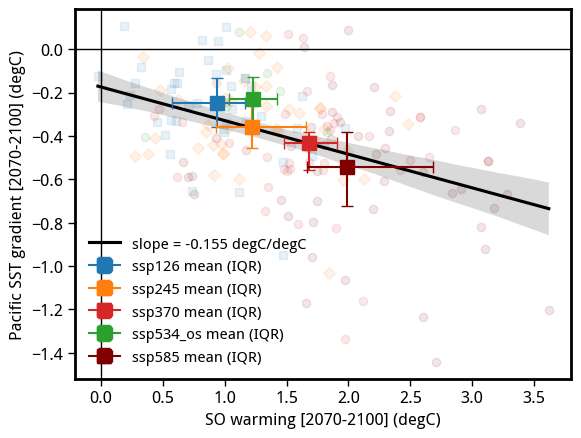

In [55]:
plt.axhline(0.0, color='k', lw=1.0)
plt.axvline(0.0, color='k', lw=1.0)
plt.scatter(so_warming1, grad_weakening1, color='tab:blue', marker='s', alpha=0.1)
plt.scatter(so_warming2, grad_weakening2, color='tab:orange', marker='D', alpha=0.1)
plt.scatter(so_warming3, grad_weakening3, color='tab:red', marker='o', alpha=0.1)
plt.scatter(so_warming5o, grad_weakening5o, color='tab:green', marker='o', alpha=0.1)
plt.scatter(so_warming5, grad_weakening5, color='maroon', marker='o', alpha=0.1)
reg_res = stats.linregress(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])
sns.regplot(x=so_warming, y=grad_weakening, scatter=False, color='k', label = f'slope = {np.round(reg_res.slope, 3)} degC/degC')

median_x = so_warming1.quantile(0.5)
median_y = grad_weakening1.quantile(0.5)
lq_x = so_warming1.quantile(0.25)
lq_y = grad_weakening1.quantile(0.25)
uq_x = so_warming1.quantile(0.75)
uq_y = grad_weakening1.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=4, color='tab:blue', label='ssp126 mean (IQR)')

median_x = so_warming2.quantile(0.5)
median_y = grad_weakening2.quantile(0.5)
lq_x = so_warming2.quantile(0.25)
lq_y = grad_weakening2.quantile(0.25)
uq_x = so_warming2.quantile(0.75)
uq_y = grad_weakening2.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=4, color='tab:orange', label='ssp245 mean (IQR)')


median_x = so_warming3.quantile(0.5)
median_y = grad_weakening3.quantile(0.5)
lq_x = so_warming3.quantile(0.25)
lq_y = grad_weakening3.quantile(0.25)
uq_x = so_warming3.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=4, color='tab:red', label='ssp370 mean (IQR)')


median_x = so_warming5o.quantile(0.5)
median_y = grad_weakening5o.quantile(0.5)
lq_x = so_warming5o.quantile(0.25)
lq_y = grad_weakening5o.quantile(0.25)
uq_x = so_warming5o.quantile(0.75)
uq_y = grad_weakening5o.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=4, color='tab:green', label='ssp534_os mean (IQR)')

median_x = so_warming5.quantile(0.5)
median_y = grad_weakening5.quantile(0.5)
lq_x = so_warming5.quantile(0.25)
lq_y = grad_weakening5.quantile(0.25)
uq_x = so_warming5.quantile(0.75)
uq_y = grad_weakening5.quantile(0.75)
plt.errorbar(median_x, median_y, yerr=[[median_y - lq_y], [uq_y - median_y]], \
             xerr=[[median_x - lq_x], [uq_x - median_x]], marker='s', markersize=10, capsize=4, color='maroon', label='ssp585 mean (IQR)')


plt.ylabel('Pacific SST gradient [2070-2100] (degC)')
plt.xlabel('SO warming [2070-2100] (degC)')
plt.legend(frameon=False, fontsize=11)
plt.savefig('./images/so_warming_sst_grad_relationship.png', dpi=300, bbox_inches='tight')
stats.spearmanr(so_warming[~(np.isnan(so_warming) | np.isnan(grad_weakening))], grad_weakening[~(np.isnan(so_warming) | np.isnan(grad_weakening))])

In [68]:
sst_grad5

<xarray.DataArray (model: 46, time: 250)>
array([[ 0.25591993, -0.07911499, -0.09083631, ..., -0.44039488,
        -0.11900125, -0.6657876 ],
       [ 0.25591993, -0.07911499, -0.09083631, ..., -0.44039488,
        -0.11900125, -0.6657876 ],
       [ 0.08288522, -1.02010175,  0.3625004 , ..., -1.23028731,
        -2.73367857, -0.54973705],
       ...,
       [-0.39567093,  0.43166742,  0.72613826, ...,  0.02052889,
        -1.52291024, -0.22216186],
       [ 0.67540218, -0.56866476,  0.28224006, ...,  0.29356796,
        -1.3979748 ,  0.42307034],
       [ 0.54305298, -0.64978254,  0.74255495, ..., -0.13973596,
        -0.63085617, -0.3129291 ]])
Coordinates:
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01
    month    (time) int64 6 6 6 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6 6 6

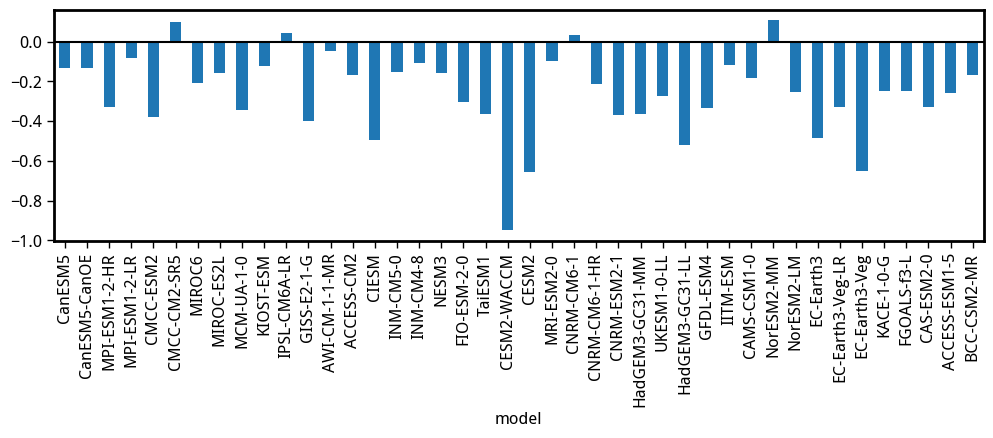

In [51]:
plt.figure(figsize=(12,3))
grad_weakening.to_series().plot.bar()
plt.axhline(0.0, color='k')

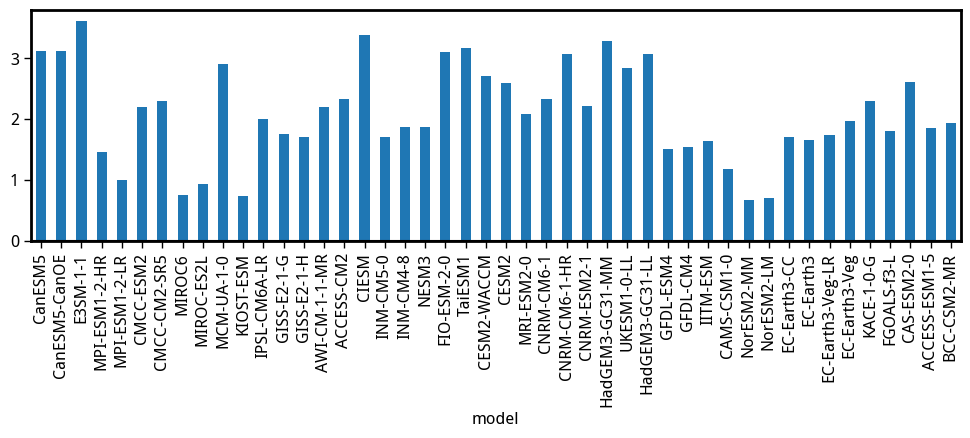

In [38]:
plt.figure(figsize=(12,3))
so_warming.to_series().plot.bar()
plt.axhline(0.0, color='k')

In [151]:
def find_signal_exceeds_noise(signal, noise):
    # signal = loess1d(arr, period=period)
    # noise = test - signal
    max_noise = np.max(noise)  # Find the maximum value of the noise array
    for i in range(len(signal)):
        if signal[i] > max_noise:
            # Check if the signal stays above the noise max for the rest of the array
            if all(signal[j] > max_noise for j in range(i, len(signal))):
                return i  # Return the first index where the condition is met
    return -1  # Return -1 if no such index exists


def find_signal_exceeds_noise3d(da, db, dim):
    return xr.apply_ufunc(find_signal_exceeds_noise, da, db, input_core_dims=[[dim], [dim]], vectorize=True, dask='allowed')

In [152]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [153]:
signal = loess3d(out1.so_sst.isel(time = slice(1,-1)), dim='time', period=30)

In [154]:
noise = out1.so_sst - signal

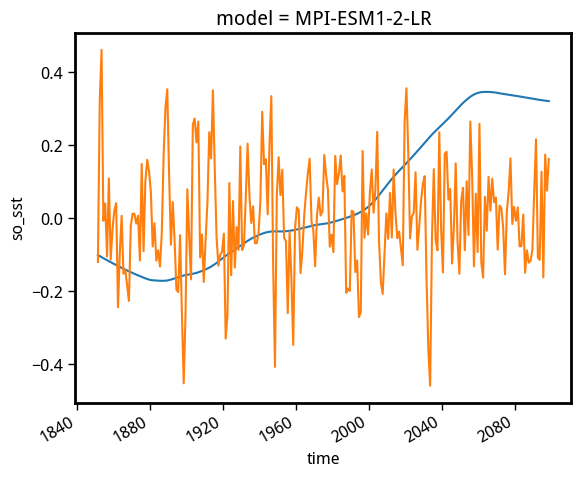

In [155]:
signal.isel(model = 3).plot()
noise.isel(model = 3).plot()

In [157]:
toe_so_sst = out1.time.dt.year[find_signal_exceeds_noise3d(signal, noise, dim='time')]

In [158]:
toe_so_sst

<xarray.DataArray 'year' (model: 42)>
array([2000, 2000, 2026, 2099, 2009, 2003, 2099, 2099, 2024, 2099, 2085,
       2099, 2020, 2031, 2010, 2014, 2004, 2031, 2002, 2023, 2025, 2026,
       2048, 2047, 2017, 2040, 2026, 2021, 2007, 2027, 2024, 2045, 2099,
       2099, 2053, 2058, 2028, 2031, 2058, 2065, 2051, 2025])
Coordinates:
    time     (model) datetime64[ns] 2000-06-01 2000-06-01 ... 2025-06-01
    month    (model) int64 ...
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'

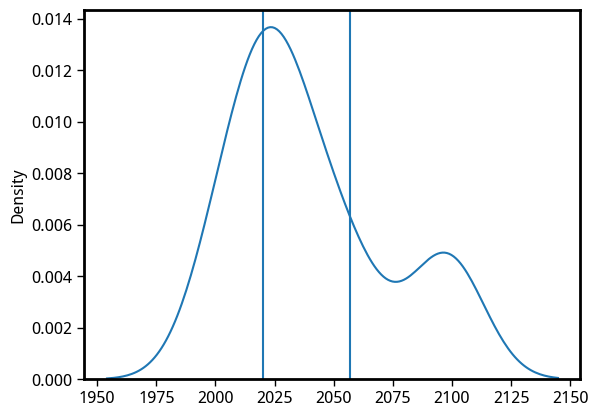

In [159]:
sns.kdeplot(toe_so_sst)
plt.axvline(toe_so_sst.quantile(0.75))
plt.axvline(toe_so_sst.quantile(0.25))

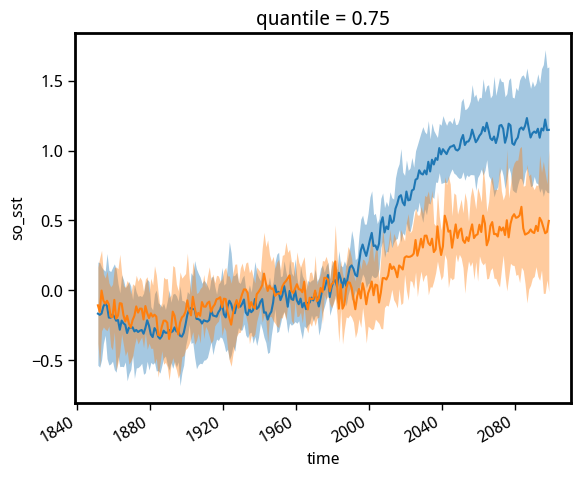

In [160]:
test = out1.isel(time = slice(1,-1)).so_sst.where(toe_so_sst < toe_so_sst.quantile(0.25))
test.mean('model').plot(color='tab:blue')
plt.fill_between(test.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:blue', alpha=0.4, lw=0.)

test = out1.isel(time = slice(1,-1)).so_sst.where(toe_so_sst > toe_so_sst.quantile(0.75))
test.mean('model').plot(color='tab:orange')
plt.fill_between(test.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:orange', alpha=0.4, lw=0.)

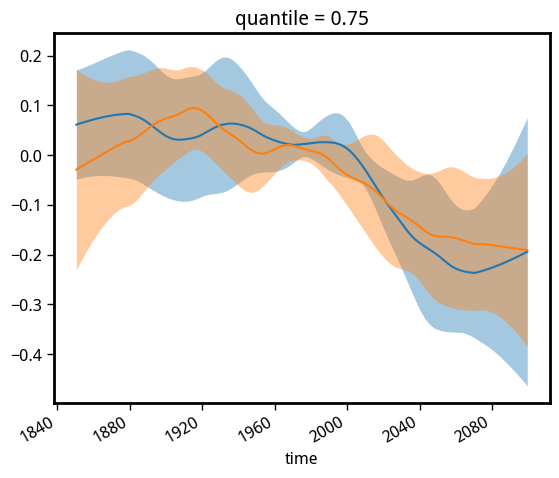

In [166]:
test = loess3d(out1.wp_sst - out1.ep_sst, dim='time', period=30).where(toe_so_sst < toe_so_sst.quantile(0.25))
test.mean('model').plot(color='tab:blue')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:blue', alpha=0.4, lw=0.)

test = loess3d(out1.wp_sst - out1.ep_sst, dim='time', period=30).where(toe_so_sst > toe_so_sst.quantile(0.75))
test.mean('model').plot(color='tab:orange')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:orange', alpha=0.4, lw=0.)

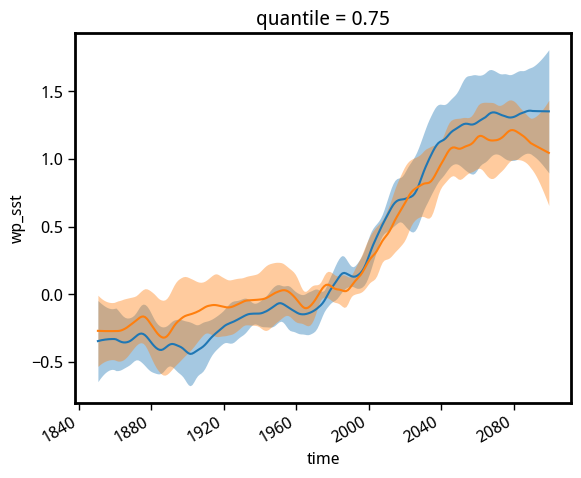

In [167]:
test = loess3d(out1.wp_sst, dim='time', period=10).where(toe_so_sst < toe_so_sst.quantile(0.25))
test.mean('model').plot(color='tab:blue')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:blue', alpha=0.4, lw=0.)

test = loess3d(out1.wp_sst, dim='time', period=10).where(toe_so_sst > toe_so_sst.quantile(0.75))
test.mean('model').plot(color='tab:orange')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:orange', alpha=0.4, lw=0.)

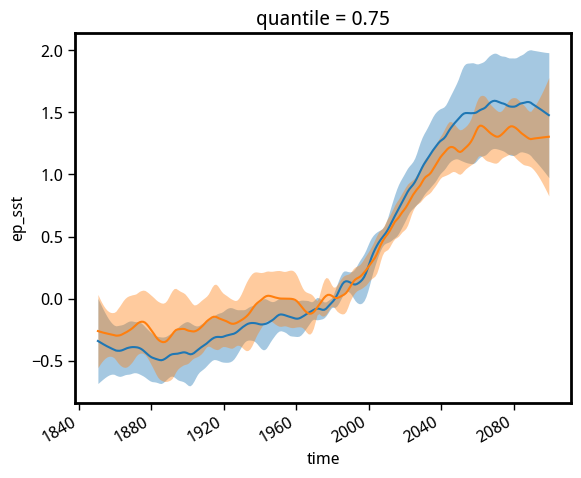

In [168]:
test = loess3d(out1.ep_sst, dim='time', period=10).where(toe_so_sst < toe_so_sst.quantile(0.25))
test.mean('model').plot(color='tab:blue')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:blue', alpha=0.4, lw=0.)

test = loess3d(out1.ep_sst, dim='time', period=10).where(toe_so_sst > toe_so_sst.quantile(0.75))
test.mean('model').plot(color='tab:orange')
plt.fill_between(out1.time.to_numpy(), test.mean('model') + test.std('model'), test.mean('model') - test.std('model'), color='tab:orange', alpha=0.4, lw=0.)